### Astrostatistic Lecture 4 

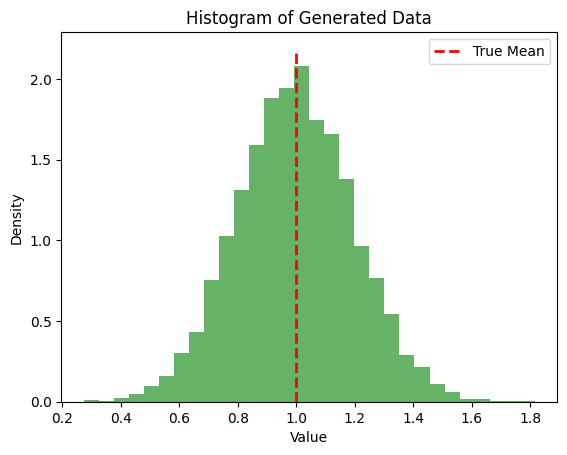

In [34]:
import numpy as np
import math 
import matplotlib.pyplot as plt
from scipy import stats 
from scipy.stats import norm

true_mean = 1
true_dev = 0.2
N = 10000
data = np.random.normal(true_mean, true_dev, N) #generating fake data from a gaussian distribution 

plt.hist(data, bins=30, density=True, alpha=0.6, color='g') #plotting the histogram of the data
plt.title('Histogram of Generated Data')
plt.vlines(true_mean, 0, plt.ylim()[1], color='r', linestyle='dashed', linewidth=2, label='True Mean') #plotting the true mean as a vertical line
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()


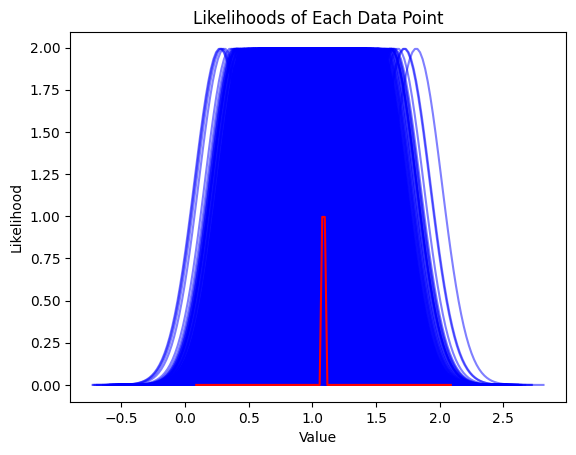

Estimated Mean: 1.0773500033552534
Difference between true mean and estimated mean: 0.07735000335525344


In [35]:
#now we need to plot the individual likelihoods of each data point
overall_array = np.array([N]) 
for point in data:
    x = np.linspace(point - 1, point + 1, 100)
    likelihood = norm.pdf(x, loc=point, scale=true_dev) #calculating the likelihood of each point
    plt.plot(x, likelihood, color='blue', alpha=0.5) #plotting the likelihoods
    overall_array = np.multiply(overall_array, likelihood)/np.sum(overall_array) #in any point of this array there's the product of all likelihoods in that point 
#now multiply all the likelihoods together to get the overall likelihood of the data
plt.plot(x, overall_array, color='red', label='Overall Likelihood') #plotting the overall likelihood
plt.title('Likelihoods of Each Data Point')
plt.xlabel('Value')
plt.ylabel('Likelihood')
plt.show()

max_likelihood=np.argsort(overall_array) #finding the index of the maximum likelihood
estimated_mean = x[max_likelihood[-1]] #the estimated mean is the value of x corresponding to the maximum likelihood
print(f'Estimated Mean: {estimated_mean}')
print(f"Difference between true mean and estimated mean: {abs(true_mean - estimated_mean)}")